# 1 - Carregando Bibliotecas e Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

try:
    from utils import iv_woe, print_correlacao, analise_quantil
except ImportError:
    sys.path.append('../utils')
    from utils import iv_woe, print_correlacao, analise_quantil

In [2]:
# Lendo o dataset diretamente do repositório do GitHub e salvando localmente
df = pd.read_csv("https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv")
df.to_csv("../data/external/desafio_nps_fase_1.csv", index=False)

## 1.1 - Visão geral do DataFrame

In [3]:
df.shape

(2500, 19)

In [4]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


# 2 - Analisando as métricas do dataframe

## 2.1 - Tipos de Colunas e dados vazios

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

Possuímos 3 diferentes tipos de colunas:
- int64: 13 colunas
- float64: 5 colunas
- str: 1 coluna

Total: 18 colunas numéricas e 1 não numérica.

Além disso, **não existem** dados nulos no dataset.

## 2.2 - Visualizando as métricas de estatística descritiva

In [6]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


# 3 - Analisando os dados em busca de insights

## 3.1 - Analisando a variável `nps_score`

Antes de analisar o NPS, é importante entender o conceito da métrica. <br>
O NPS (Net Promoter Score) é uma métrica usada para medir o nível de satisfação e lealdade dos clientes em relação a uma empresa, produto ou serviço.

Ele se baseia em uma única pergunta:
> “Em uma escala de 0 a 10, o quanto você recomendaria nossa empresa/produto/serviço a um amigo ou colega?”

**Classificação dos Clientes**:
- Promotores (9-10): Clientes fiéis e entusiastas que promovem a marca.
- Passivos/Neutros (7-8): Satisfeitos, mas não leais, vulneráveis à concorrência.
- Detratores (0-6): Clientes insatisfeitos que podem prejudicar a reputação.

In [7]:
# Métricas de estatística descritiva do NPS
df[['nps_score']].describe()

,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


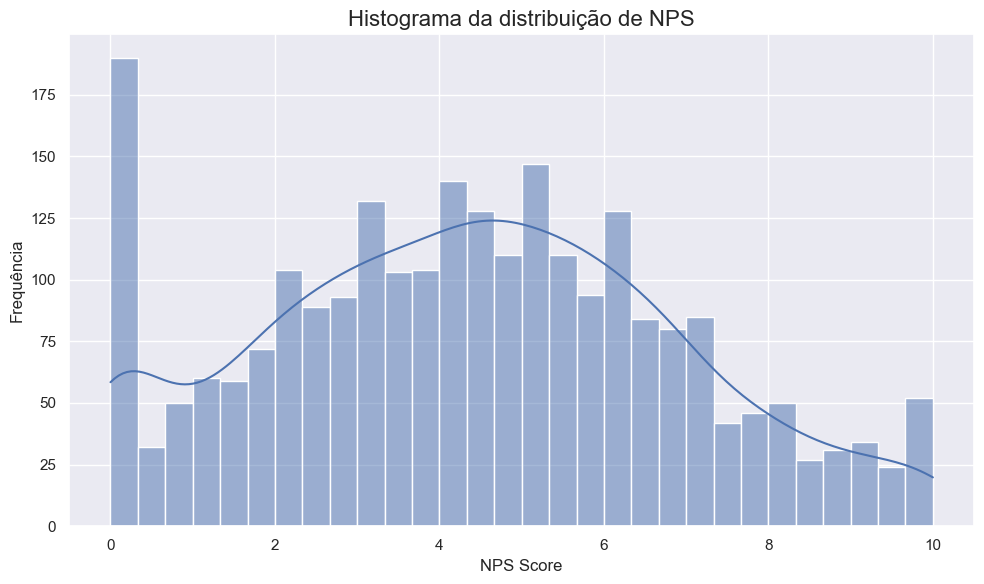

In [8]:
# Visualizando a distribuição do NPS de forma gráfica

# Estilo visual
sns.set_theme(style="darkgrid")

# Criar o histograma
plt.figure(figsize=(10, 6))
sns.histplot(
    df.nps_score,
    bins=30,
    kde=True,
    color="#4C72B0"
)

# Títulos e rótulos
plt.title("Histograma da distribuição de NPS", fontsize=16)
plt.xlabel("NPS Score", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

plt.tight_layout()
plt.show()

A partir dessa visualização, é possível notar que existem concentrações em notas muito baixas - próximas ou iguais a zero - e muito altas - próximas ou iguais a 10. <br>
Fora destas concentrações, a distribuição apresenta formato aproximadamente normal, com leve assimetria e limites superiores e inferiores impostos pela escala.

Para as seguintes análises, iremos analisar:
1. A base completa
2. A base de clientes apenas com NPS 0 -> causas da nota 0 <br>
3. A base de clientes apenas com NPS 10 -> causas da nota 10 <br>
4. A base de clientes com NPS aproximadamente normal

## 3.2 - Analisando o Dataset completo

In [9]:
df.shape

(2500, 19)

### 3.2.1 - Verificando a correlação entre as variáveis numéricas do dataset

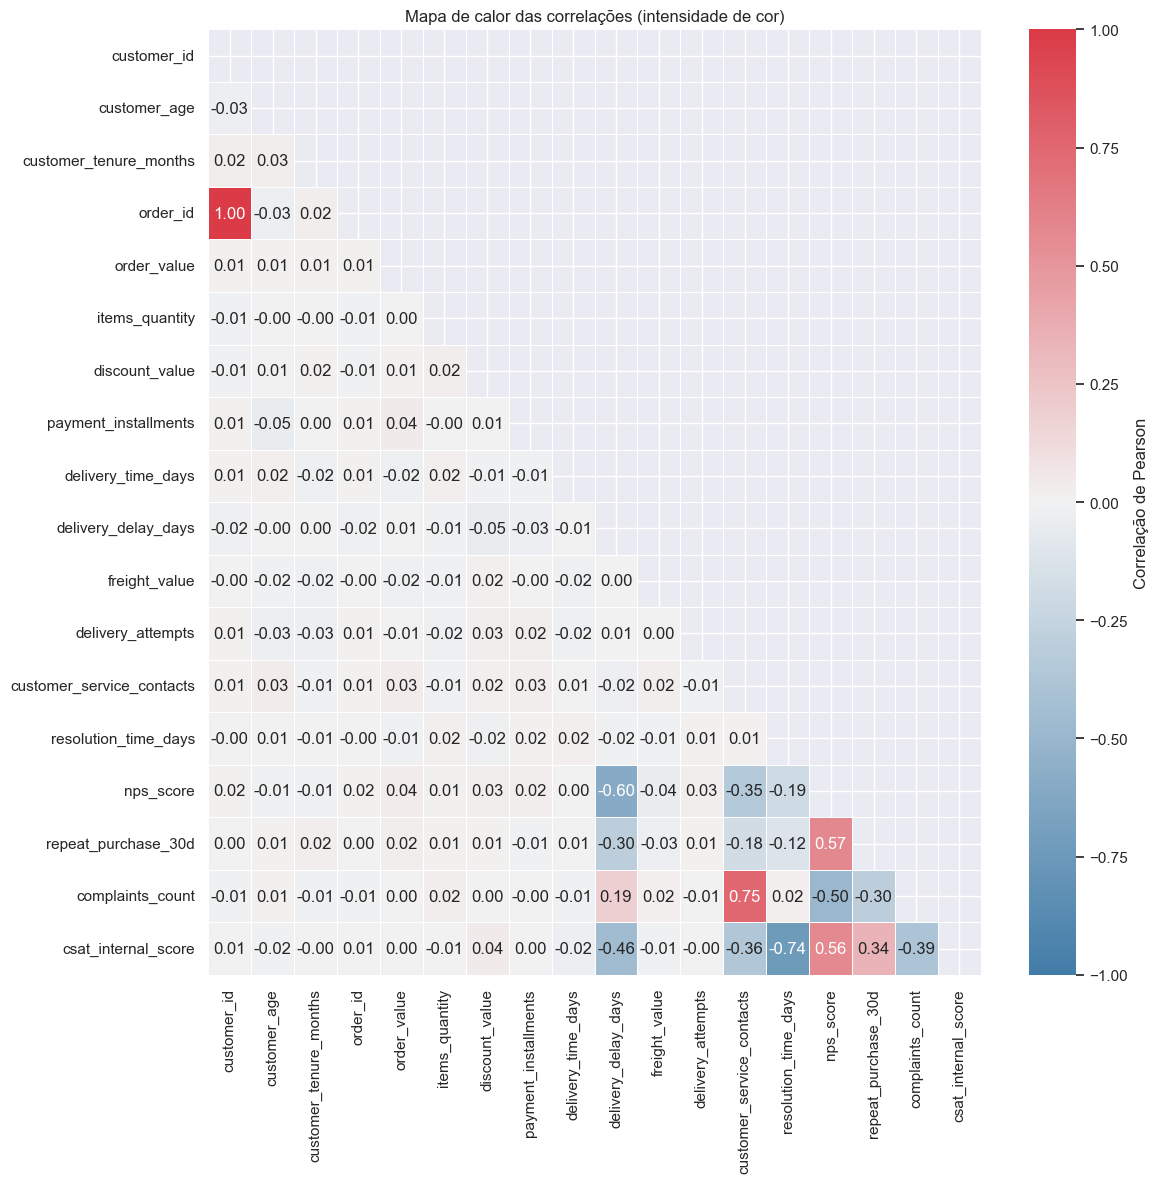

In [10]:
resultado = print_correlacao(df)

Observando a correlação entre NPS e as outras variáveis, é possível notar a relação com 6 features que se destacam. <br> <br>
**4 correlações negativas**:
- delivery_delay_days (-0.60)
- complaints_count (-0.50)
- customer_service_contacts (-0.35)
- resolution_time_days (-0.19)

**2 correlações positivas**:
- repeat_purchase_30d (0.57)
- csat_internal_score (0.56)

Visto que a única variável categórica `customer_region` não foi contemplada nesta análise, será feito uma analise apartada. <br>

À princípio, supos-se que a região do cliente pode ter influência no atraso da entrega, visto que a malha logística pode variar de acordo com a região. <br>
Dessa forma, faremos uma análise tanto do NPS quanto do atraso de entrega por região.

In [11]:
df.groupby('customer_region').agg({'nps_score': 'mean', 'delivery_delay_days': 'mean'})

,nps_score,delivery_delay_days
customer_region,,
Centro-Oeste,4.209829,2.222222
Nordeste,4.421649,2.185567
Norte,4.382609,2.144269
Sudeste,4.373846,2.217308
Sul,4.490979,2.168906


A partir desta análise, é possível notar que essa variável não exerce grande influência tanto no `nps_score`, quanto em `delivery_delay_days`.

### 3.2.2 - Analisando o comportamento das features em relação ao NPS

In [12]:
df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='str')

#### Variável `customer_age`

         min_val  max_val
quantil                  
1             18       23
2             24       28
3             29       34
4             35       38
5             39       43
6             44       48
7             49       54
8             55       59
9             60       64
10            65       69


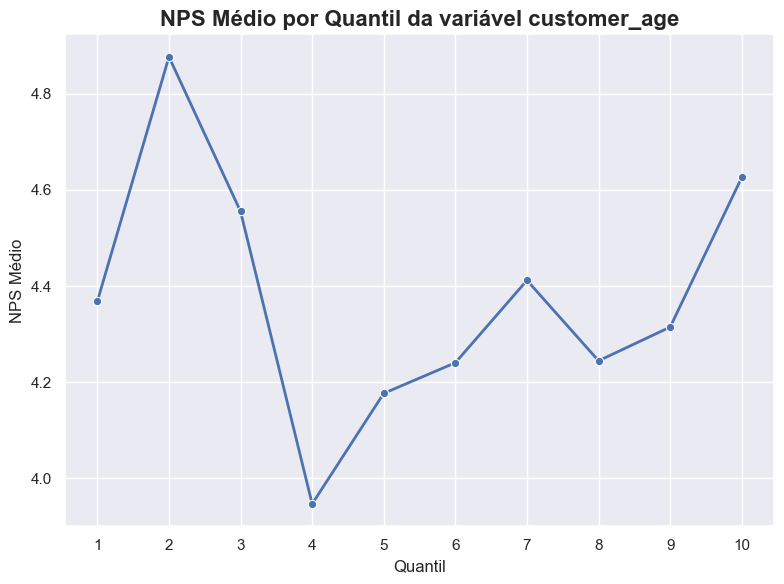

In [13]:
analise_quantil(df, 'customer_age')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `customer_tenure_months`

         min_val  max_val
quantil                  
1              1       13
2             14       25
3             26       37
4             38       50
5             51       62
6             63       74
7             75       84
8             85       96
9             97      109
10           110      119


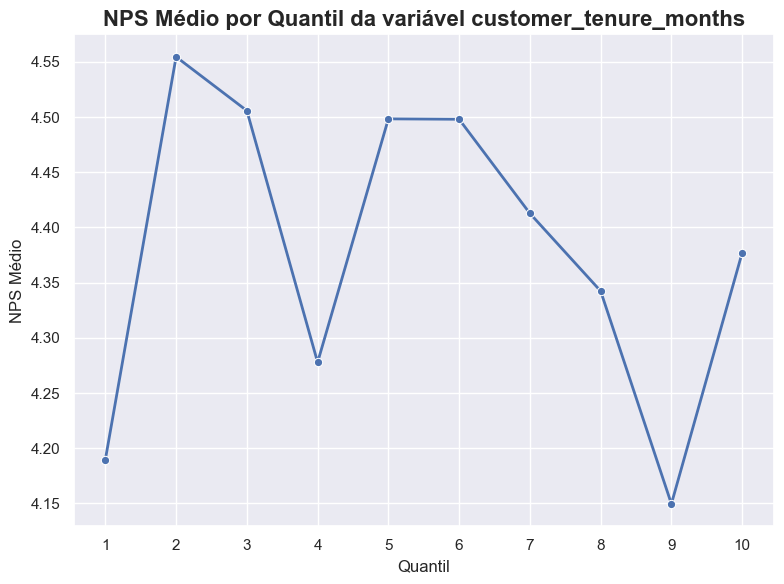

In [14]:
analise_quantil(df, 'customer_tenure_months')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `order_value`

         min_val  max_val
quantil                  
1           7.76   126.52
2         126.73   191.56
3         191.86   249.43
4         250.52   312.04
5         312.27   375.46
6         375.57   446.05
7         446.12   525.26
8         525.67   639.58
9         639.78   825.63
10        825.72  1983.81


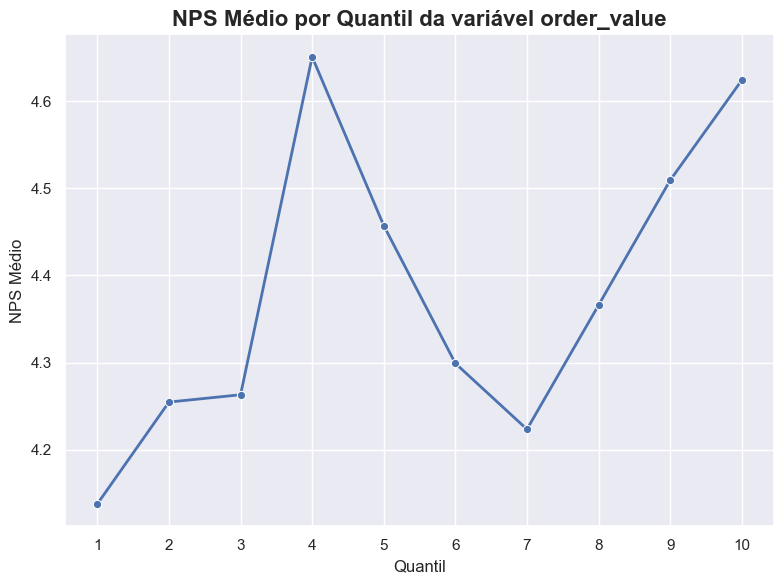

In [16]:
analise_quantil(df, 'order_value')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `items_quantity`

         min_val  max_val
quantil                  
1              1        2
2              3        3
3              4        4
4              5        5
5              6        6


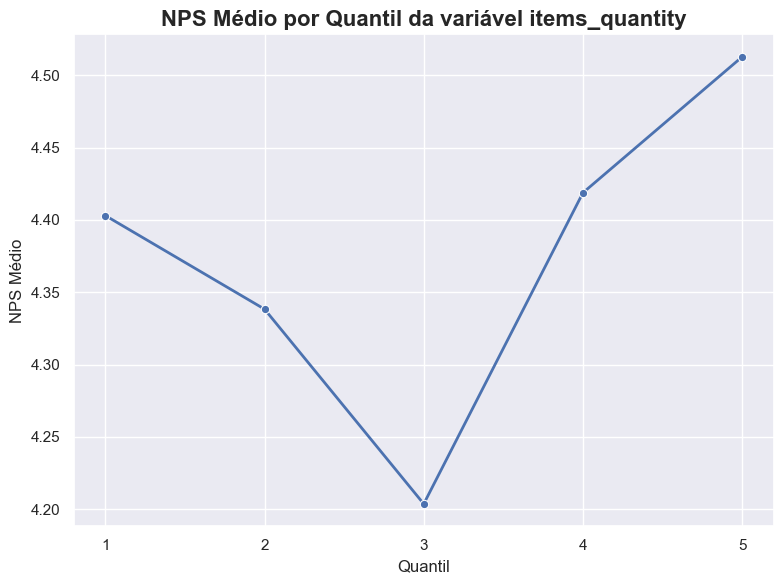

In [17]:
analise_quantil(df, 'items_quantity')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `discount_value`

         min_val  max_val
quantil                  
1           0.02     3.05
2           3.06     6.81
3           6.83    11.18
4          11.19    15.61
5          15.62    20.89
6          20.98    27.55
7          27.57    36.04
8          36.10    47.45
9          47.48    68.44
10         68.52   230.33


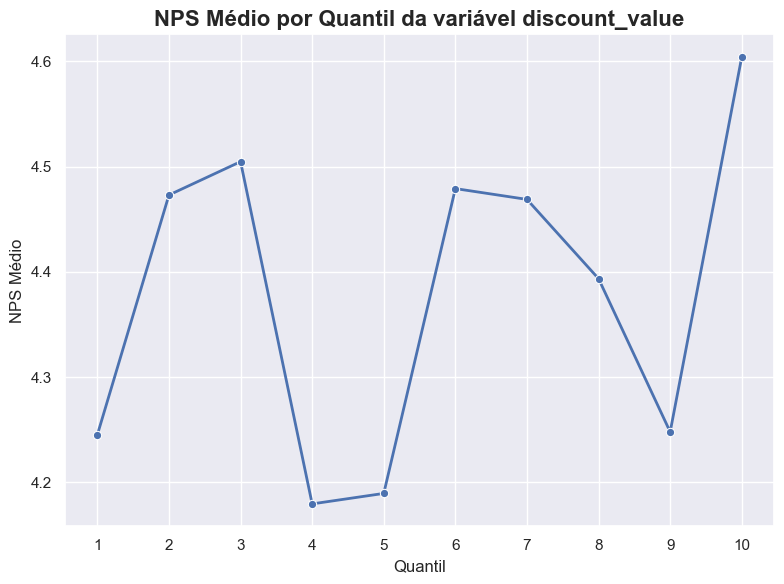

In [18]:
analise_quantil(df, 'discount_value')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `payment_installments`

         min_val  max_val
quantil                  
1              1        2
2              3        3
3              4        4
4              5        5
5              6        6
6              7        7
7              8        8
8              9        9
9             10       10
10            11       11


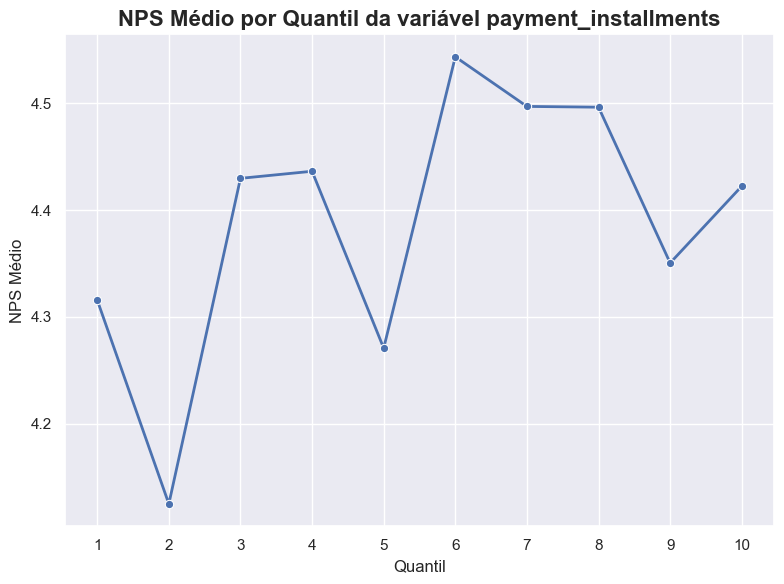

In [19]:
analise_quantil(df, 'payment_installments')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `delivery_time_days`

         min_val  max_val
quantil                  
1              2        3
2              4        4
3              5        5
4              6        7
5              8        8
6              9        9
7             10       11
8             12       12
9             13       13
10            14       14


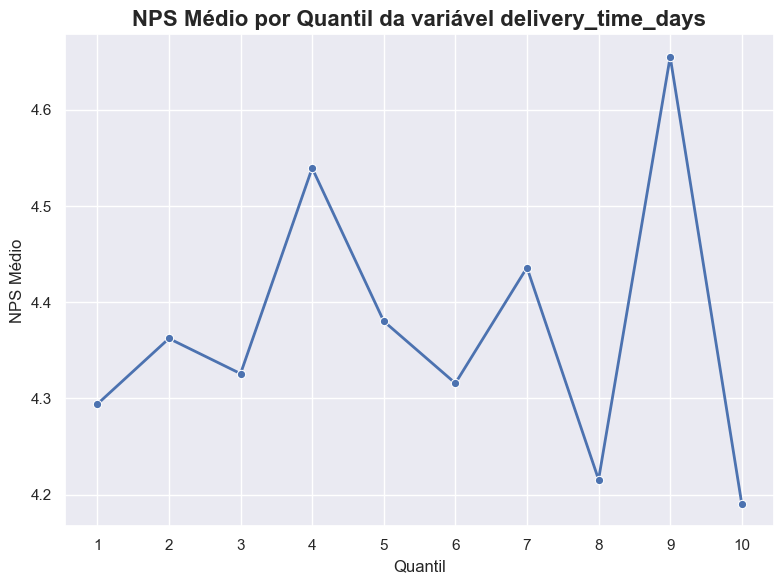

In [20]:
analise_quantil(df, 'delivery_time_days')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `delivery_delay_days`

         min_val  max_val
quantil                  
1              0        1
2              2        2
3              3        3
4              4        4
5              5        8


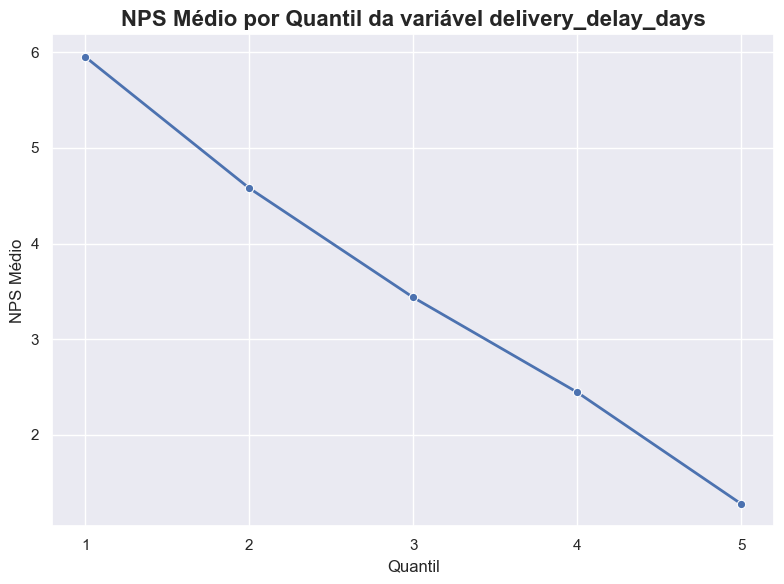

In [21]:
analise_quantil(df, 'delivery_delay_days')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre o atraso na entrega e o NPS.

#### Variável `freight_value`

         min_val  max_val
quantil                  
1           2.62    22.33
2          22.38    27.94
3          27.96    31.93
4          31.94    35.22
5          35.24    38.50
6          38.52    41.54
7          41.56    44.64
8          44.65    48.09
9          48.10    53.94
10         53.95    76.13


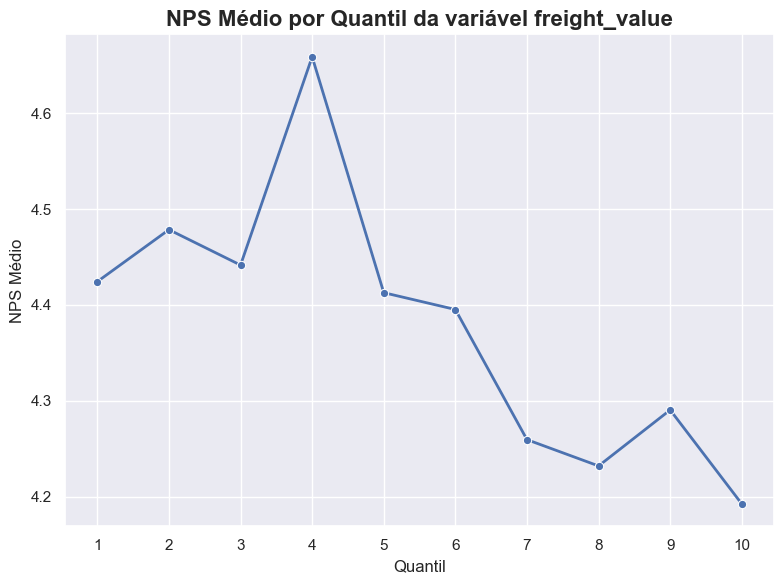

In [22]:
analise_quantil(df, 'freight_value')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `delivery_attempts`

         min_val  max_val
quantil                  
1              1        2
2              3        3


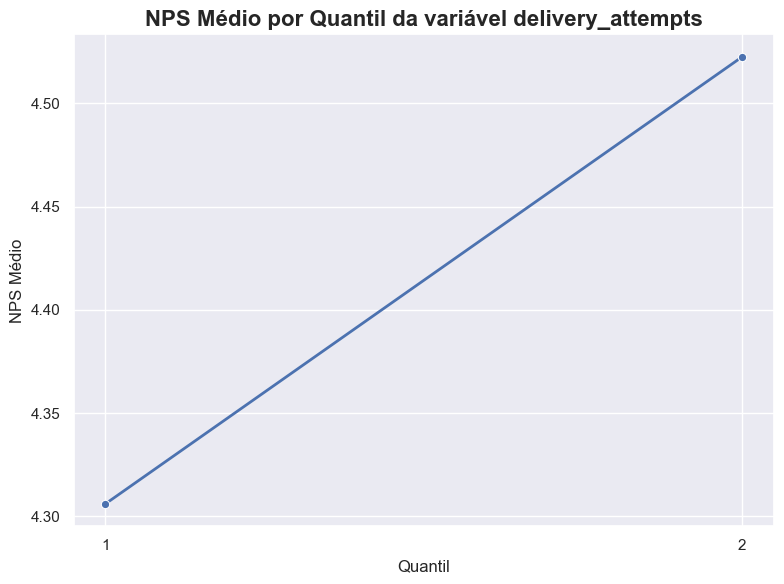

In [23]:
analise_quantil(df, 'delivery_attempts')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `customer_service_contacts`

         min_val  max_val
quantil                  
1              0        1
2              2        2
3              3        3
4              4        7


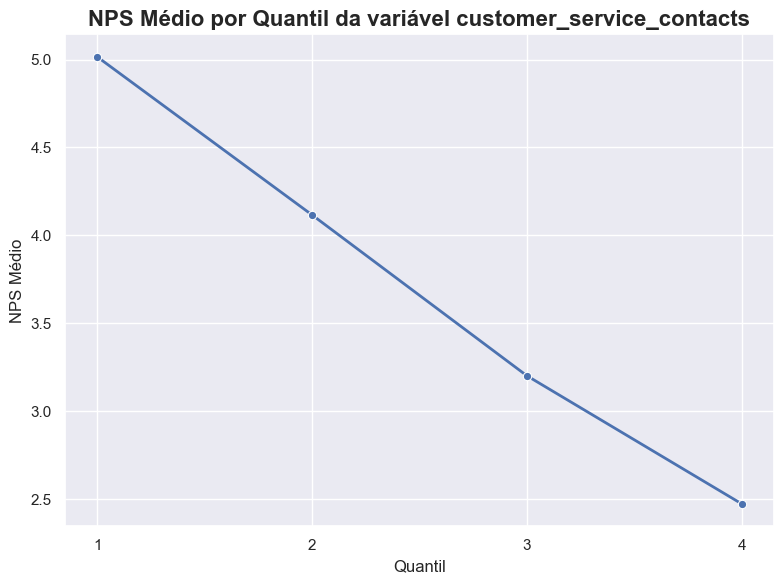

In [24]:
analise_quantil(df, 'customer_service_contacts')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre a quantidade de contatos com o SAC e o NPS.

#### Variável `resolution_time_days`

         min_val  max_val
quantil                  
1              0        1
2              2        2
3              3        3
4              4        4
5              5        6
6              7        7
7              8        8
8              9        9
9             10       10
10            11       11


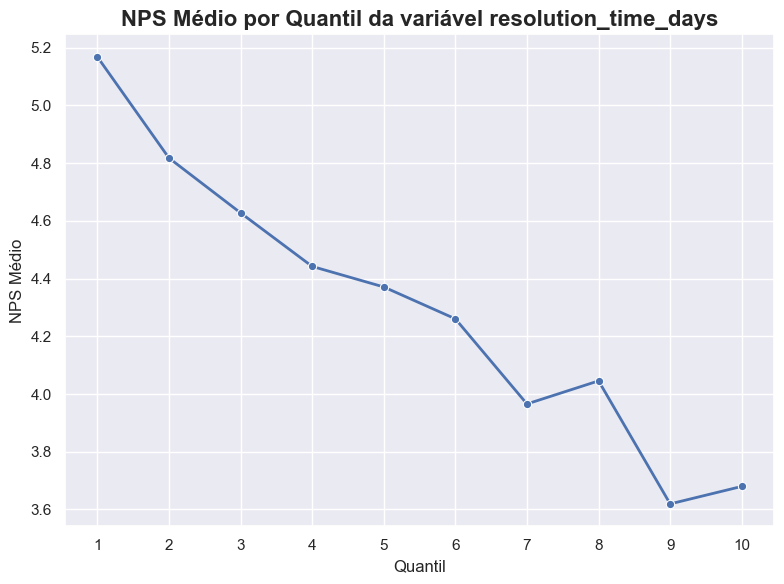

In [25]:
analise_quantil(df, 'resolution_time_days')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre a quantidade de dias até a resolução e o NPS.

#### Variável `complaints_count`

         min_val  max_val
quantil                  
1              0        2
2              3        3
3              4        4
4              5        5
5              6        6
6              7        7
7              8       11


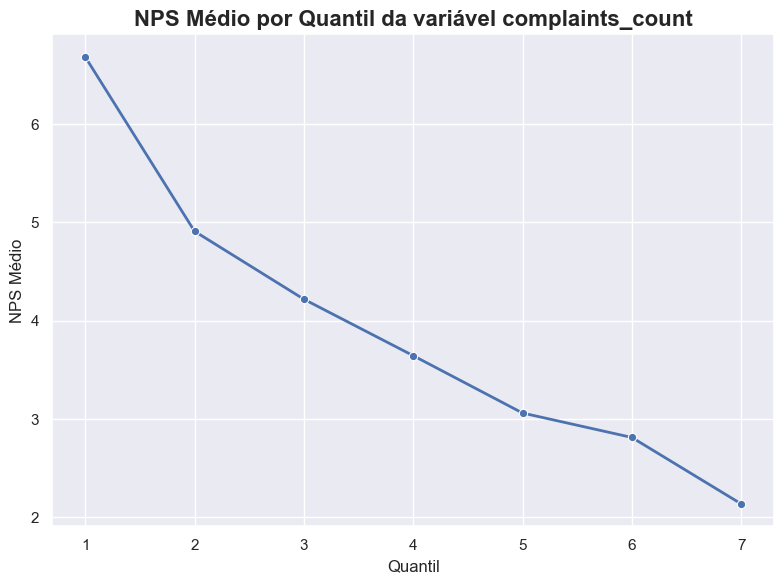

In [27]:
analise_quantil(df, 'complaints_count')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre a quantidade de reclamações e o NPS.

#### Variável `csat_internal_score`

         min_val  max_val
quantil                  
1            0.0      0.2
2            0.3      1.2
3            1.3      2.0
4            2.1      2.8
5            2.9      3.5
6            3.6      4.3
7            4.4      5.2
8            5.3      6.3
9            6.4     10.0


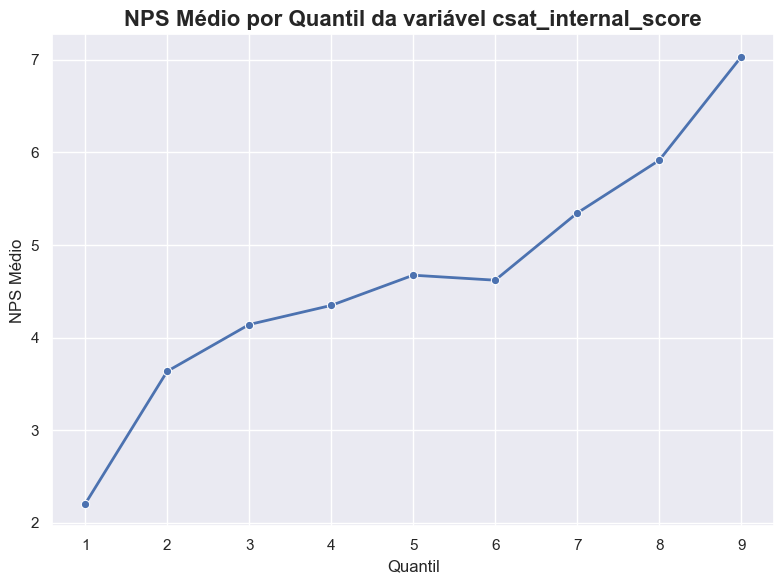

In [ ]:
analise_quantil(df, 'csat_internal_score')

É possível observar mudança significativa no NPS e uma relação diretamente proporcional entre o atraso na entrega e o csat_internal_score.

**OBS**: <br>
As relações das colunas customer_id e order_id não foram estudadas porque são identificadores do cliente e não trazem informação relevante para o estudo. <br>
Além disso, não é possível realizar a mesma análise para as colunas customer_region (categórica) e repeat_purchase_30d (booleana)

## 3.3 - Analisando o Dataset com `nps_score` == 0

In [34]:
df_zero = df[df['nps_score'] == 0]

In [35]:
# Dimensão do dataset
df_zero.shape

(158, 20)

In [36]:
# Analisando as estatísticas descritivas do subset
df_zero.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,quantil
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.0,158.0,158.000000,158.000000,158.0
mean,1167.993671,44.645570,61.715190,51167.993671,417.211203,3.322785,28.307468,6.094937,8.164557,4.107595,39.106456,1.943038,2.651899,6.348101,0.0,0.0,5.759494,0.701899,1.0
std,645.949876,13.720632,33.793696,645.949876,281.148379,1.640526,25.820934,3.117217,3.855447,1.482748,12.022180,0.823567,1.427336,3.311680,0.0,0.0,1.835358,1.260951,0.0
min,8.000000,18.000000,1.000000,50008.000000,14.580000,1.000000,0.100000,1.000000,2.000000,1.000000,6.130000,1.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000,1.0
25%,611.750000,35.000000,34.250000,50611.750000,218.547500,2.000000,8.780000,3.000000,5.000000,3.000000,30.180000,1.000000,1.250000,4.000000,0.0,0.0,4.000000,0.000000,1.0
50%,1159.000000,45.500000,61.500000,51159.000000,368.575000,3.000000,20.920000,6.000000,8.000000,4.000000,40.285000,2.000000,3.000000,6.500000,0.0,0.0,6.000000,0.000000,1.0
75%,1737.000000,56.750000,89.750000,51737.000000,526.862500,5.000000,41.777500,9.000000,12.000000,5.000000,47.222500,3.000000,4.000000,9.000000,0.0,0.0,7.000000,0.900000,1.0
max,2454.000000,69.000000,118.000000,52454.000000,1842.300000,6.000000,129.590000,11.000000,14.000000,8.000000,66.870000,3.000000,7.000000,11.000000,0.0,0.0,10.000000,5.200000,1.0


É possível notar que, quando o NPS é zerado, não existe casos em que houve compra dentro de uma janela de 30 dias.

### 3.3.1 - Comparando a diferença entre as médias do dataset completo e do subset com NPS igual a zero

In [49]:
df_compare = pd.DataFrame()

df_compare['zero_mean'] = df_zero.describe().loc['mean']
df_compare['complete_mean'] = df.describe().loc['mean']
df_compare['perc_diff'] = 100*(df_compare['complete_mean'] - df_compare['zero_mean'])/df_compare['complete_mean']

df_compare['perc_diff']

customer_id                    6.597867
customer_age                  -2.879458
customer_tenure_months        -0.640532
order_id                       0.160986
order_value                    3.925885
items_quantity                 4.264584
discount_value                 4.834835
payment_installments          -1.514602
delivery_time_days            -1.777075
delivery_delay_days          -87.801524
freight_value                 -2.327339
delivery_attempts              3.119367
customer_service_contacts    -74.512946
resolution_time_days         -15.723007
nps_score                    100.000000
repeat_purchase_30d          100.000000
complaints_count             -38.769605
csat_internal_score           76.138879
quantil                        0.000000
Name: perc_diff, dtype: float64

In [14]:
(df['nps_score'] == 10).sum()

np.int64(42)

In [13]:
df['nps_score'].value_counts()

nps_score
0.0    158
4.5     49
4.9     44
3.9     44
3.4     42
      ... 
9.3      6
9.0      5
9.8      4
9.9      3
9.7      3
Name: count, Length: 101, dtype: int64

In [11]:
df_zero = df[df['nps_score'] == 0]

In [12]:
df_prom = df[df['nps_score'] >= 9]

In [13]:
df_prom.shape

(110, 19)

In [14]:
df.shape

(2500, 19)

In [15]:
df[df['delivery_delay_days']==8]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
772,773,21,Norte,89,50773,542.58,1,3.45,5,14,8,42.85,3,1,8,0.0,0,4,0.0
954,955,45,Sudeste,15,50955,174.88,3,15.02,9,10,8,40.97,1,2,8,0.0,0,5,0.0
1597,1598,50,Norte,118,51598,316.61,4,39.48,5,4,8,36.26,2,2,1,0.0,0,4,0.0


In [16]:
df_zero.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.0,158.0,158.000000,158.000000
mean,1167.993671,44.645570,61.715190,51167.993671,417.211203,3.322785,28.307468,6.094937,8.164557,4.107595,39.106456,1.943038,2.651899,6.348101,0.0,0.0,5.759494,0.701899
std,645.949876,13.720632,33.793696,645.949876,281.148379,1.640526,25.820934,3.117217,3.855447,1.482748,12.022180,0.823567,1.427336,3.311680,0.0,0.0,1.835358,1.260951
min,8.000000,18.000000,1.000000,50008.000000,14.580000,1.000000,0.100000,1.000000,2.000000,1.000000,6.130000,1.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000
25%,611.750000,35.000000,34.250000,50611.750000,218.547500,2.000000,8.780000,3.000000,5.000000,3.000000,30.180000,1.000000,1.250000,4.000000,0.0,0.0,4.000000,0.000000
50%,1159.000000,45.500000,61.500000,51159.000000,368.575000,3.000000,20.920000,6.000000,8.000000,4.000000,40.285000,2.000000,3.000000,6.500000,0.0,0.0,6.000000,0.000000
75%,1737.000000,56.750000,89.750000,51737.000000,526.862500,5.000000,41.777500,9.000000,12.000000,5.000000,47.222500,3.000000,4.000000,9.000000,0.0,0.0,7.000000,0.900000
max,2454.000000,69.000000,118.000000,52454.000000,1842.300000,6.000000,129.590000,11.000000,14.000000,8.000000,66.870000,3.000000,7.000000,11.000000,0.0,0.0,10.000000,5.200000


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analise_decil(df, col, n=10):
    # Criar decis
    df = df.copy()
    df["decil"] = pd.qcut(df[col], n, labels=False, duplicates="drop") + 1


    limites = (
        df.groupby("decil")[col]
          .agg(min_val="min", max_val="max")
    )

    print(limites)

    # Agregar dados
    df_plot = (
        df.groupby("decil", as_index=False)
          .agg(nps_medio=("nps_score", "mean"))
    )

    # Estilo visual
    sns.set_theme(style="whitegrid", palette="viridis")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_plot,
        x="decil",
        y="nps_medio",
        marker="o",
        linewidth=2
    )

    # Ajustes visuais
    plt.title("NPS Médio por Décil", fontsize=16, weight="bold")
    plt.xlabel("Décil", fontsize=12)
    plt.ylabel("NPS Médio", fontsize=12)
    plt.xticks(range(1, df_plot["decil"].max() + 1))

    plt.tight_layout()
    plt.show()

    df.drop(columns=["decil"], inplace=True)

       min_val  max_val
decil                  
1            0        1
2            2        2
3            3        3
4            4        4
5            5        8


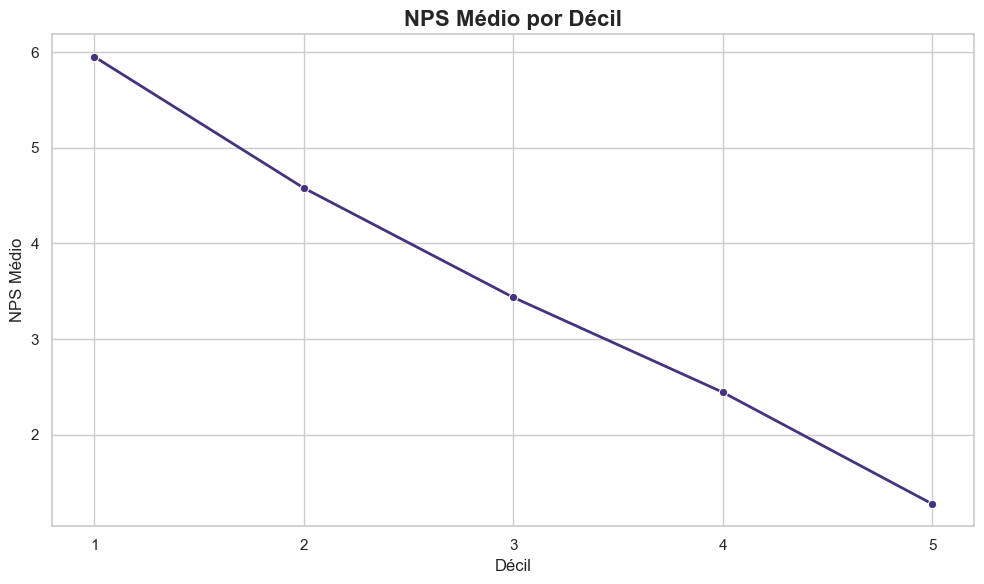

In [29]:
analise_decil(df, 'delivery_delay_days')

       min_val  max_val
decil                  
1         7.76   126.52
2       126.73   191.56
3       191.86   249.43
4       250.52   312.04
5       312.27   375.46
6       375.57   446.05
7       446.12   525.26
8       525.67   639.58
9       639.78   825.63
10      825.72  1983.81


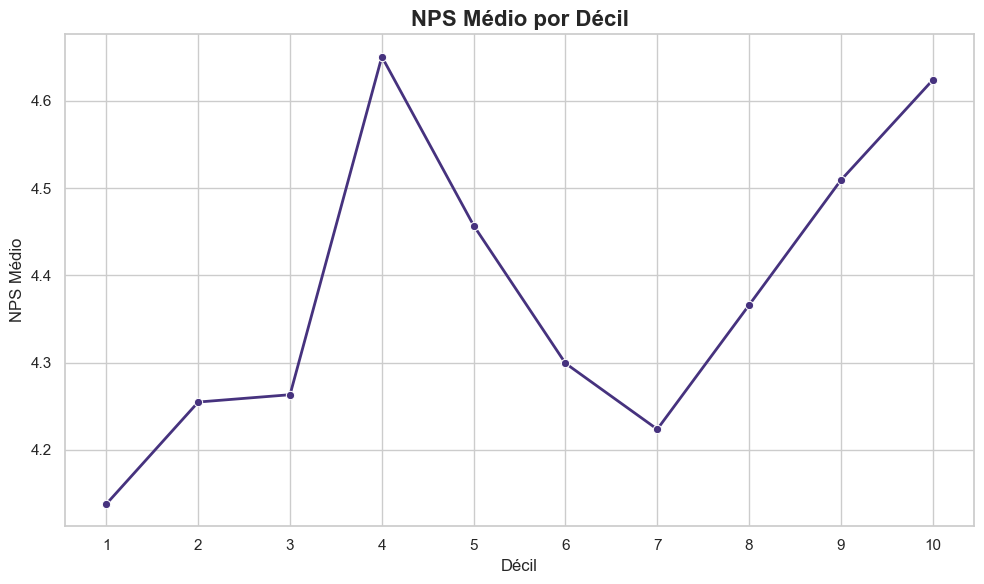

In [30]:
analise_decil(df, 'order_value', n=10)

<Axes: xlabel='delivery_delay_days', ylabel='nps_score'>

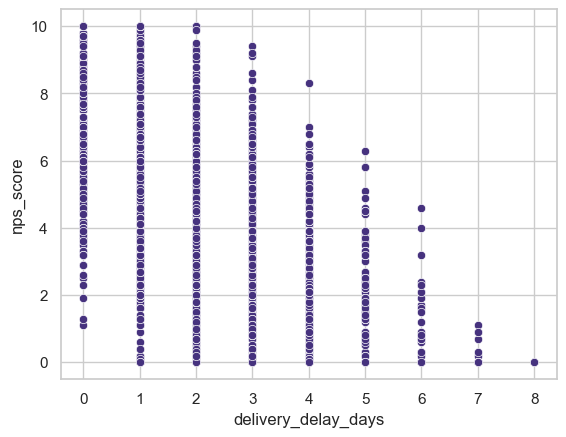

In [31]:
sns.scatterplot(df, x='delivery_delay_days', y='nps_score')

<Axes: xlabel='customer_region', ylabel='delivery_time_days'>

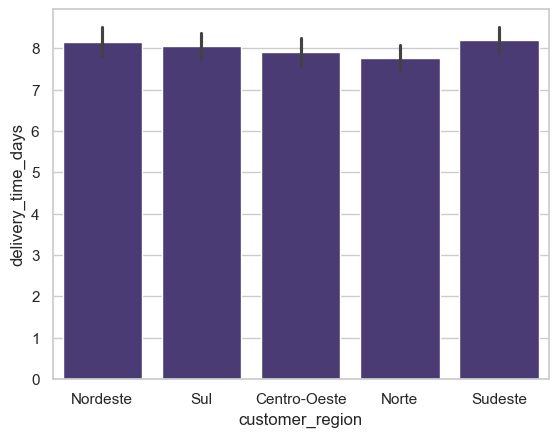

In [32]:
sns.barplot(df, x='customer_region', y='delivery_time_days')

<Axes: xlabel='decil'>

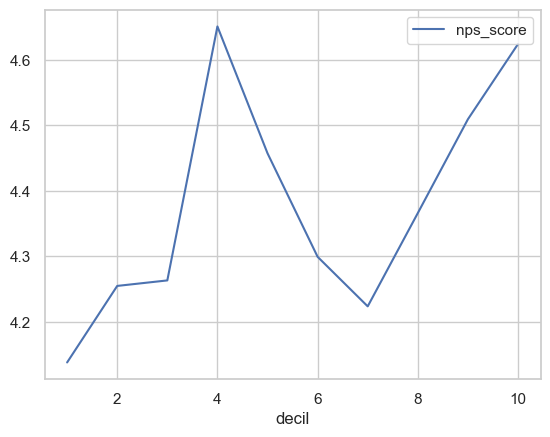

In [18]:
labels = [i for i in range(1, 11)]

df["decil"] = pd.qcut(df["order_value"], 10, labels=labels)
sns.lineplot(df.groupby('decil').agg({'nps_score':'mean'}))

# Vários métodos de transformar a coluna de região em numérica
- OneHotEncoder
- MeanInput
- etc

In [19]:
def print_correlacao(df):
  # 2) Selecionar apenas colunas numéricas (em um caso real: df.select_dtypes)
  num_df = df.select_dtypes(include=[np.number])

  # 3) Calcular a matriz de correlação (Pearson por padrão)
  corr = num_df.corr(method='pearson')

  # 4) Plotar como heatmap com cores por intensidade
  plt.figure(figsize=(12, 12))
  # Colormap divergente enfatiza sinais positivos/negativos
  cmap = sns.diverging_palette(240, 10, as_cmap=True)  # azul->vermelho

  # Máscara para mostrar apenas triângulo inferior (opcional)
  mask = np.triu(np.ones_like(corr, dtype=bool))

  ax = sns.heatmap(
      corr,
      mask=mask,
      cmap=cmap,
      vmin=-1, vmax=1,  # intensidade fixa em [-1, 1]
      center=0,
      annot=True, fmt=".2f",  # anotações opcionais
      linewidths=0.5,
      cbar_kws={"label": "Correlação de Pearson"}
  )
  ax.set_title("Mapa de calor das correlações (intensidade de cor)")
  plt.tight_layout()

  # Retornar algumas informações úteis
  corr_summary = corr.round(2).to_dict()
  {'arquivo': 'correlation_heatmap_exemplo.png', 'dimensoes': corr.shape, 'amostra_corr': list(corr_summary.items())[:3]}

  plt.show()


In [20]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
decil                        0
dtype: int64

In [21]:
df.dtypes

customer_id                     int64
customer_age                    int64
customer_region                   str
customer_tenure_months          int64
order_id                        int64
order_value                   float64
items_quantity                  int64
discount_value                float64
payment_installments            int64
delivery_time_days              int64
delivery_delay_days             int64
freight_value                 float64
delivery_attempts               int64
customer_service_contacts       int64
resolution_time_days            int64
nps_score                     float64
repeat_purchase_30d             int64
complaints_count                int64
csat_internal_score           float64
decil                        category
dtype: object

### Classificação dos Clientes:
- Promotores (9-10): Clientes fiéis e entusiastas que promovem a marca.
- Passivos/Neutros (7-8): Satisfeitos, mas não leais, vulneráveis à concorrência.
- Detratores (0-6): Clientes insatisfeitos que podem prejudicar a reputação.

In [22]:
index_prom = df['nps_score']>=9
index_neut = ((df['nps_score']<9) & (df['nps_score']>=7))
index_detr = df['nps_score']<7

In [23]:
# df.loc[index_prom, 'classificacao'] = 'Promotores'
# df.loc[index_neut, 'classificacao'] = 'Neutros'
# df.loc[index_detr, 'classificacao'] = 'Detratores'

df.loc[index_prom, 'classificacao'] = 0
df.loc[index_neut, 'classificacao'] = 0
df.loc[index_detr, 'classificacao'] = 1

In [24]:
df.dtypes

customer_id                     int64
customer_age                    int64
customer_region                   str
customer_tenure_months          int64
order_id                        int64
order_value                   float64
items_quantity                  int64
discount_value                float64
payment_installments            int64
delivery_time_days              int64
delivery_delay_days             int64
freight_value                 float64
delivery_attempts               int64
customer_service_contacts       int64
resolution_time_days            int64
nps_score                     float64
repeat_purchase_30d             int64
complaints_count                int64
csat_internal_score           float64
decil                        category
classificacao                 float64
dtype: object

In [25]:
df['classificacao'] = df['classificacao'].astype(int)
newDF,woeDF = iv_woe(df.drop(columns=['customer_region']), target='classificacao')

Information value of customer_id is 0.023822
Information value of customer_age is 0.087312
Information value of customer_tenure_months is 0.019884
Information value of order_id is 0.023822
Information value of order_value is 0.025407
Information value of items_quantity is 0.006398
Information value of discount_value is 0.029839
Information value of payment_installments is 0.011588
Information value of delivery_time_days is 0.031325
Information value of delivery_delay_days is 1.568505
Information value of freight_value is 0.018506
Information value of delivery_attempts is 0.02115
Information value of customer_service_contacts is 0.43111
Information value of resolution_time_days is 0.167429
Information value of nps_score is 9.858712
Information value of repeat_purchase_30d is 4.780957
Information value of complaints_count is 1.295487
Information value of csat_internal_score is 1.348664
Information value of decil is 0.025407


### Features Importantes
- repeat_purchase -> data leakage
- delivery_delay_days
- csat_internal_score
- complaints_count


### Features com baixo ou médio poder pre
- customer_service_contacts
- resolution_time_days
- customer_age
- order_value
- discount_value
- delivery_time_days
- delivery_attempts

In [26]:
df.nps_score.mean()

np.float64(4.3786)

In [27]:
df_detr = df[index_detr]

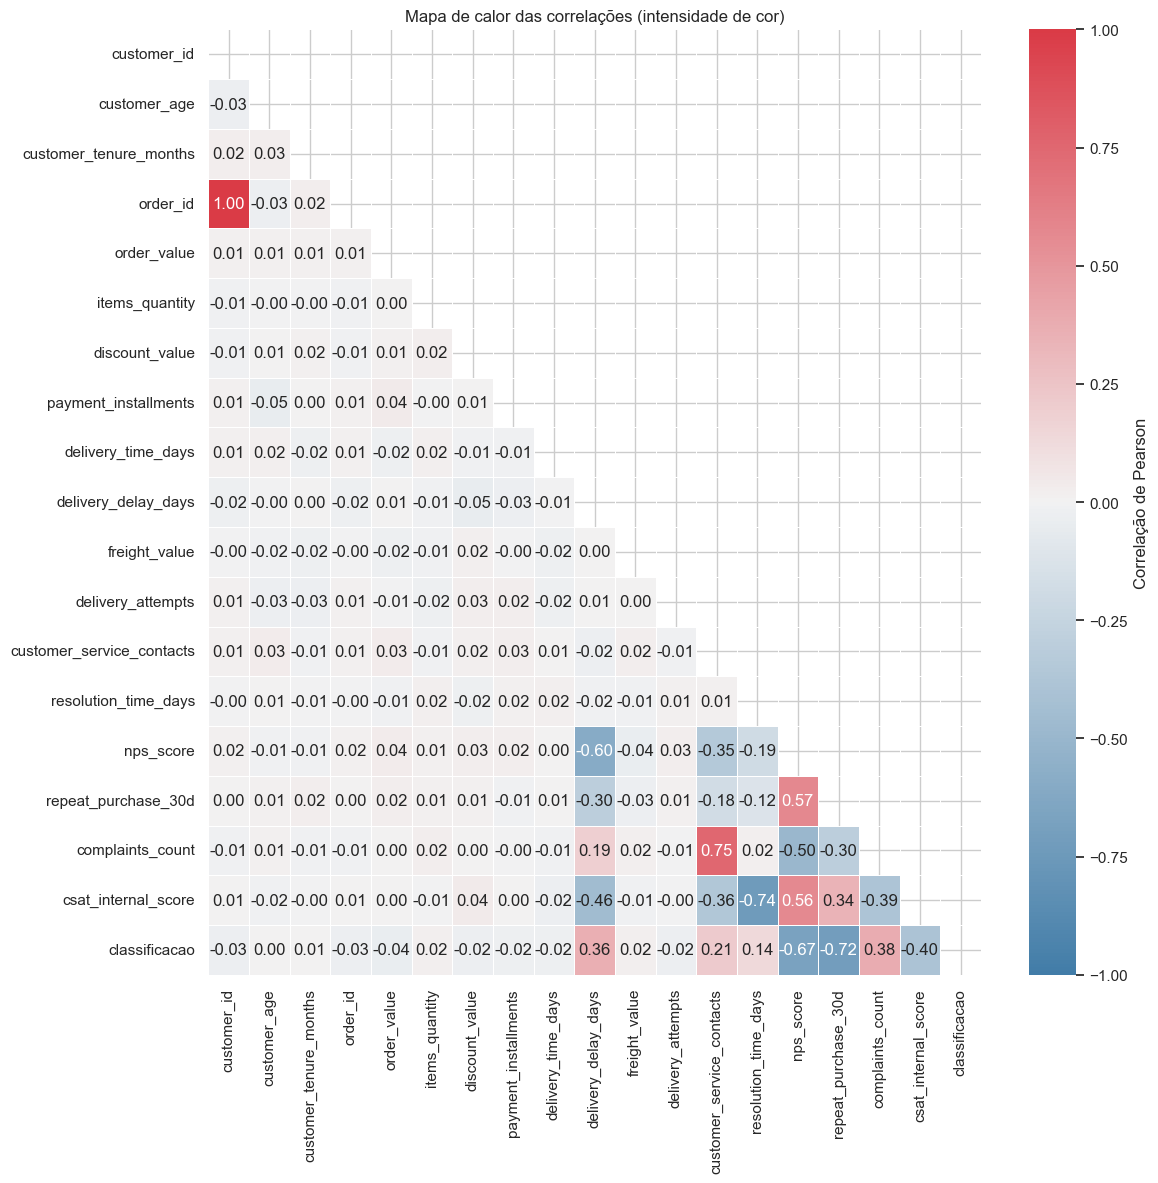

In [28]:
print_correlacao(df)

In [29]:
df.groupby('classificacao').agg(mean_nps=('nps_score', 'mean'), median_nps=('nps_score', 'median'))

,mean_nps,median_nps
classificacao,,
0,8.298977,8.1
1,3.651778,3.9


In [30]:
df.classificacao.value_counts()

classificacao
1    2109
0     391
Name: count, dtype: int64